# 手写数字识别（MNIST）— 完整教学 Notebook

**受众**: AI 导论课程学生，有 Python 基础，初次接触深度学习。

**前置知识**: Python、NumPy 基础、机器学习基本概念（训练/测试、分类）。

**学习目标**:
1. 理解图像数据如何进入神经网络（预处理 → DataLoader → batch）
2. 理解 CNN 的结构与每层的作用（卷积 / 池化 / 全连接）
3. 理解训练循环的每一步：前向传播 → 损失计算 → 反向传播 → 参数更新
4. 学会解读训练曲线、混淆矩阵、误分类样例
5. 能够用训练好的模型对新图片进行预测并导出结果

**使用方式**: 从头到尾逐 cell 运行，阅读每个 markdown cell 的讲解。

> 本 Notebook 完全自包含，不依赖 `src/` 目录，可在任意环境中独立运行。


## 0) 环境检查与依赖导入

首先检查 Python 版本和关键依赖是否可用。如果导入失败，请运行：

```bash
pip install torch torchvision numpy pillow matplotlib scikit-learn pandas
```


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import json
import csv
import random

# 配置 matplotlib 中文显示（无中文字体时会 fallback，不影响运行）
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print(f"Python 版本: {sys.version.split()[0]}")
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")
print(f"当前工作目录: {Path.cwd()}")


Python 版本: 3.13.9
PyTorch 版本: 2.11.0+cu128
CUDA 可用: False
当前工作目录: e:\ALL\学习\AI导论作业-识别手写数字\.worktrees\baseline


## 1) 实验配置与可复现性

深度学习的实验可复现非常重要。这里我们：
- 用 `dataclass` 集中管理所有超参数（改一处即可）
- 固定随机种子（Python random、NumPy、PyTorch）
- 自动创建输出目录结构

**为什么要固定随机种子？**
- 权重初始化是随机的 → 不同 seed 会导致不同结果
- 数据划分（train/val split）是随机的
- 固定 seed 后，每次运行得到完全一致的结果，便于调试和对比实验


In [2]:
from dataclasses import dataclass

@dataclass
class Config:
    """实验配置：把所有超参数集中在一起。"""
    project_root: Path = Path(".")
    dataset_name: str = "mnist"        # "mnist" 或 "folder"
    batch_size: int = 64               # 每批样本数
    validation_split: float = 0.2      # 验证集比例
    image_size: int = 28               # 输入图像尺寸
    num_classes: int = 10              # 分类类别数（0-9）
    in_channels: int = 1               # 输入通道数（灰度图=1）
    learning_rate: float = 1e-3        # 学习率
    epochs: int = 3                    # 训练轮数
    seed: int = 42                     # 随机种子
    num_workers: int = 0               # 数据加载线程数


# 创建配置实例
config = Config(
    project_root=Path(".").resolve(),
    dataset_name="mnist",
    batch_size=64,
    validation_split=0.2,
    image_size=28,
    learning_rate=1e-3,
    epochs=3,
    seed=42,
)

# 固定随机种子
random.seed(config.seed)
np.random.seed(config.seed)
torch.manual_seed(config.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.seed)

# 创建输出目录
outputs_dir = config.project_root / "outputs"
for sub in ["checkpoints", "logs", "figures", "predictions"]:
    (outputs_dir / sub).mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"使用设备: {device}")
print(f"随机种子: {config.seed}")
print(f"输出目录: {outputs_dir}")
print("超参数:")
for k, v in config.__dict__.items():
    print(f"  {k}: {v}")


使用设备: cpu
随机种子: 42
输出目录: E:\ALL\学习\AI导论作业-识别手写数字\.worktrees\baseline\outputs
超参数:
  project_root: E:\ALL\学习\AI导论作业-识别手写数字\.worktrees\baseline
  dataset_name: mnist
  batch_size: 64
  validation_split: 0.2
  image_size: 28
  num_classes: 10
  in_channels: 1
  learning_rate: 0.001
  epochs: 3
  seed: 42
  num_workers: 0


## 2) 数据理解（EDA）

在训练模型之前，必须先理解数据。这一节我们回答三个问题：

1. **数据长什么样？** — 随机展示一些样本图片
2. **类别是否均衡？** — 如果某类样本特别少，模型可能学不好
3. **像素值的数值分布？** — 决定用什么归一化策略

MNIST 数据集简介：
- 70,000 张 28×28 的灰度手写数字图片
- 训练集 60,000 张，测试集 10,000 张
- 10 个类别（数字 0-9）
- 每张图只有一个数字，居中显示


MNIST 训练集样本数: 60000

每个数字的样本数:
  数字 0:  5923 张  █████████████████████████████
  数字 1:  6742 张  █████████████████████████████████
  数字 2:  5958 张  █████████████████████████████
  数字 3:  6131 张  ██████████████████████████████
  数字 4:  5842 张  █████████████████████████████
  数字 5:  5421 张  ███████████████████████████
  数字 6:  5918 张  █████████████████████████████
  数字 7:  6265 张  ███████████████████████████████
  数字 8:  5851 张  █████████████████████████████
  数字 9:  5949 张  █████████████████████████████


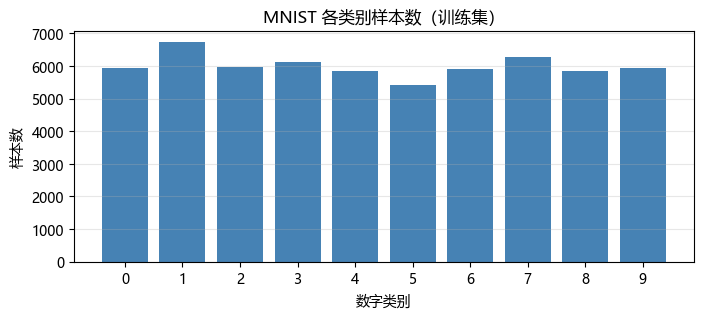


结论：MNIST 类别基本均衡，每类约 6000 张，不需要做类别不平衡处理。


In [3]:
# 加载原始 MNIST（仅 ToTensor，不做归一化，便于观察原始像素）
raw_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

print(f"MNIST 训练集样本数: {len(raw_dataset)}")

# ---- 类别分布 ----
targets = raw_dataset.targets.numpy()
counts = np.bincount(targets, minlength=10)
print("\n每个数字的样本数:")
for i, c in enumerate(counts):
    print(f"  数字 {i}: {c:5d} 张  {'█' * (c // 200)}")

plt.figure(figsize=(8, 3))
plt.bar(range(10), counts, color="steelblue")
plt.title("MNIST 各类别样本数（训练集）")
plt.xlabel("数字类别")
plt.ylabel("样本数")
plt.xticks(range(10))
plt.grid(axis="y", alpha=0.3)
plt.show()

print("\n结论：MNIST 类别基本均衡，每类约 6000 张，不需要做类别不平衡处理。")


### 2.1) 随机样本可视化

下面随机抽 16 张图片展示。观察：
- 同一个数字的不同写法（有些人写 7 加横杠，有些不加）
- 图片的清晰度和笔画粗细差异
- 有些数字连人都不容易分辨（比如 4 和 9，3 和 8）


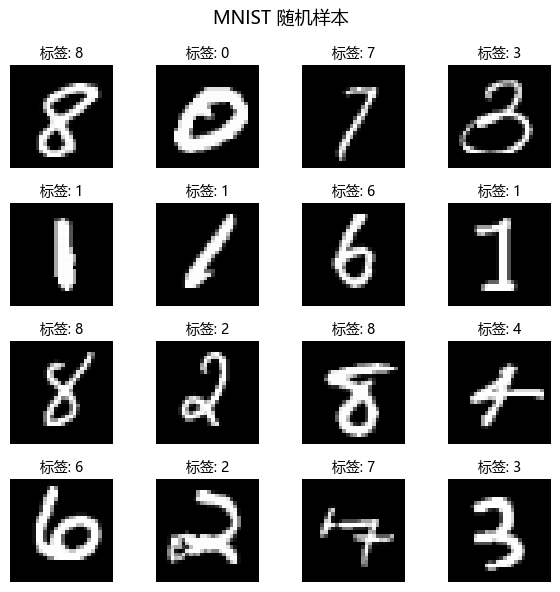

In [4]:
rng = np.random.default_rng(config.seed)
indices = rng.choice(len(raw_dataset), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for ax, idx in zip(axes.flatten(), indices):
    img, label = raw_dataset[int(idx)]
    ax.imshow(img.squeeze(0), cmap="gray")
    ax.set_title(f"标签: {int(label)}", fontsize=10)
    ax.axis("off")
plt.suptitle("MNIST 随机样本", fontsize=13)
plt.tight_layout()
plt.show()


### 2.2) 像素值分布

`transforms.ToTensor()` 会把 PIL 图像的 `[0, 255]` 映射到 `[0.0, 1.0]`。

观察像素分布可以看到：MNIST 大部分像素是黑色背景（值为 0），数字笔画只占一小部分。


像素范围: [0.0000, 1.0000]
像素均值: 0.1465
像素标准差: 0.3236
非零像素比例: 20.98%

观察：MNIST 图片大部分区域是黑色背景(值为0)，数字笔画只占小部分像素。


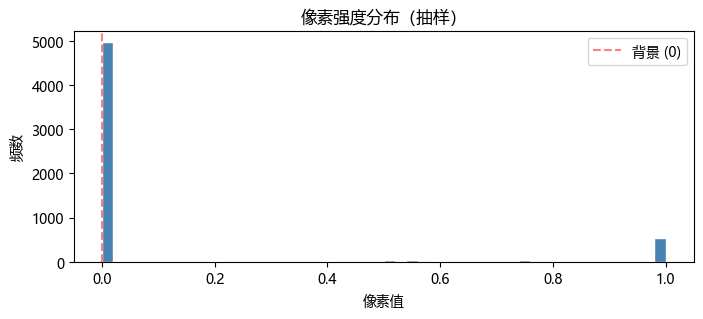

In [5]:
# 抽样 8 张图，合并所有像素值
sample_pixels = []
for i in rng.choice(len(raw_dataset), size=8, replace=False):
    img, _ = raw_dataset[int(i)]
    sample_pixels.append(img.flatten().numpy())
sample_pixels = np.concatenate(sample_pixels)

print(f"像素范围: [{sample_pixels.min():.4f}, {sample_pixels.max():.4f}]")
print(f"像素均值: {sample_pixels.mean():.4f}")
print(f"像素标准差: {sample_pixels.std():.4f}")
print(f"非零像素比例: {(sample_pixels > 0).mean():.2%}")
print()
print("观察：MNIST 图片大部分区域是黑色背景(值为0)，数字笔画只占小部分像素。")

plt.figure(figsize=(8, 3))
plt.hist(sample_pixels, bins=50, color="steelblue", edgecolor="white")
plt.title("像素强度分布（抽样）")
plt.xlabel("像素值")
plt.ylabel("频数")
plt.axvline(x=0, color="red", linestyle="--", alpha=0.5, label="背景 (0)")
plt.legend()
plt.show()


## 3) 图像预处理（Transform Pipeline）

深度学习中，原始图片不能直接喂给模型，需要经过 **预处理流水线**：

| 步骤 | 操作 | 作用 |
|------|------|------|
| Resize | 缩放到固定尺寸 | 确保所有输入尺寸一致 |
| ToTensor | PIL Image → Tensor，值域 [0,255] → [0,1] | 转为模型可处理的张量格式 |
| Normalize | `(x - mean) / std` | 零中心化 + 归一化，加速收敛 |

**为什么用 `mean=0.5, std=0.5`？**

$$x_{norm} = \frac{x - 0.5}{0.5} = 2x - 1$$

这等价于把 [0, 1] 线性映射到 [-1, 1]，简单且有效。对于 MNIST，这是一个常用技巧。

**数据增强（Data Augmentation）** — 训练时可选：
- `RandomRotation`: 随机旋转 ±8°，模拟不同书写角度
- `RandomAffine`: 随机平移 ±8%，模拟位置偏移

> 关键原则：数据增强**只在训练时用**，验证/测试时不用。


标签: 8
ToTensor 后范围:    [0.0000, 1.0000]
Normalize 后范围:   [-1.0000, 1.0000]
Normalize 后均值:   -0.6781
Normalize 后标准差: 0.6714


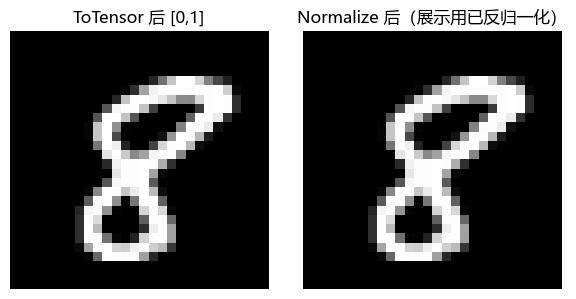

In [7]:
def build_transform(image_size: int = 28, augment: bool = False):
    """构建图像预处理流水线。

    参数:
        image_size: 输出图像尺寸
        augment: 是否启用数据增强（仅训练时使用）
    """
    ops = [transforms.Resize((image_size, image_size))]

    if augment:
        ops.extend([
            transforms.RandomRotation(8),
            transforms.RandomAffine(degrees=0, translate=(0.08, 0.08)),
        ])

    ops.extend([
        transforms.ToTensor(),                # [0,255] → [0,1]
        transforms.Normalize((0.5,), (0.5,)), # [0,1] → [-1,1]
    ])
    return transforms.Compose(ops)


# ---- 对比归一化前后的数值 ----
# 注意：raw_dataset 在上面构建时已经用过 ToTensor()，所以这里取出来的是 Tensor 而不是 PIL。
img_tensor, label = raw_dataset[int(indices[0])]
pil_img = transforms.ToPILImage()(img_tensor)

raw_tensor = transforms.ToTensor()(pil_img)                 # 仅 ToTensor
full_tensor = build_transform(28, augment=False)(pil_img)    # 完整预处理

print(f"标签: {int(label)}")
print(f"ToTensor 后范围:    [{raw_tensor.min():.4f}, {raw_tensor.max():.4f}]")
print(f"Normalize 后范围:   [{full_tensor.min():.4f}, {full_tensor.max():.4f}]")
print(f"Normalize 后均值:   {full_tensor.mean():.4f}")
print(f"Normalize 后标准差: {full_tensor.std():.4f}")

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(raw_tensor.squeeze(0), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("ToTensor 后 [0,1]")
axes[0].axis("off")

# 反归一化以便可视化
unorm = (full_tensor * 0.5 + 0.5).clamp(0, 1)
axes[1].imshow(unorm.squeeze(0), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Normalize 后（展示用已反归一化）")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 4) DataLoader：批次数据的形状与含义

`DataLoader` 负责：
1. 将数据集划分为 batch（每批 64 张图）
2. 打乱训练数据（shuffle=True）
3. 并行加载（num_workers）

我们先创建 train/val split，然后检查一个 batch 的张量形状。

**关键形状**：
- `images`: `(B, C, H, W)` = `(64, 1, 28, 28)`
  - B = batch size，C = 通道数（灰度=1），H/W = 高/宽
- `labels`: `(B,)` — 每个样本的类别索引


训练 batch 数: 750
验证 batch 数: 188

images.shape = (64, 1, 28, 28)  # (batch, channel, height, width)
labels.shape = (64,)
labels[:10] = [8, 6, 5, 8, 6, 3, 0, 8, 0, 0]
images 数值范围: [-1.0000, 1.0000]


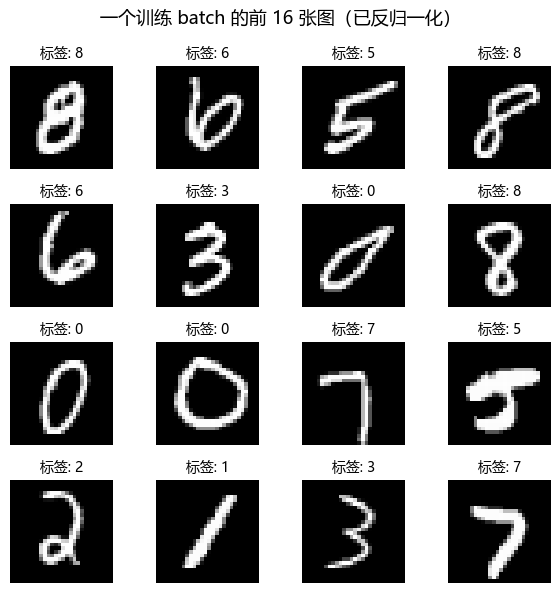

In [8]:
def create_dataloaders(cfg: Config):
    """创建训练集和验证集的 DataLoader。"""
    # 加载完整训练集
    dataset = datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=build_transform(cfg.image_size, augment=False),
    )

    # 按比例划分训练/验证
    val_size = max(1, int(len(dataset) * cfg.validation_split))
    train_size = len(dataset) - val_size

    generator = torch.Generator().manual_seed(cfg.seed)
    train_subset, val_subset = random_split(
        dataset, [train_size, val_size], generator=generator
    )

    train_loader = DataLoader(
        train_subset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers
    )
    val_loader = DataLoader(
        val_subset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers
    )
    return train_loader, val_loader


train_loader, val_loader = create_dataloaders(config)
print(f"训练 batch 数: {len(train_loader)}")
print(f"验证 batch 数: {len(val_loader)}")

# 取一个 batch 观察
images, labels = next(iter(train_loader))
print(f"\nimages.shape = {tuple(images.shape)}  # (batch, channel, height, width)")
print(f"labels.shape = {tuple(labels.shape)}")
print(f"labels[:10] = {labels[:10].tolist()}")
print(f"images 数值范围: [{images.min():.4f}, {images.max():.4f}]")

# 展示 batch 中的前 16 张图（反归一化后显示）
show = (images[:16] * 0.5 + 0.5).clamp(0, 1)
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for ax, img, y in zip(axes.flatten(), show, labels[:16]):
    ax.imshow(img.squeeze(0), cmap="gray")
    ax.set_title(f"标签: {int(y)}", fontsize=10)
    ax.axis("off")
plt.suptitle("一个训练 batch 的前 16 张图（已反归一化）", fontsize=13)
plt.tight_layout()
plt.show()


## 5) CNN 模型：SmallCNN 的结构详解

我们的模型是一个小型卷积神经网络，分两部分：

### 特征提取器（features）
| 层 | 输入形状 | 输出形状 | 说明 |
|----|----------|----------|------|
| Conv2d(1→32, 3×3) | (1,28,28) | (32,28,28) | 32 个 3×3 卷积核 |
| ReLU | — | — | 非线性激活 |
| MaxPool2d(2×2) | (32,28,28) | (32,14,14) | 2×2 池化，尺寸减半 |
| Conv2d(32→64, 3×3) | (32,14,14) | (64,14,14) | 64 个 3×3 卷积核 |
| ReLU | — | — | 非线性激活 |
| MaxPool2d(2×2) | (64,14,14) | (64,7,7) | 2×2 池化，尺寸减半 |

### 分类器（classifier）
| 层 | 输入 | 输出 | 说明 |
|----|------|------|------|
| Flatten | (64,7,7)=3136 | 3136 | 展平为向量 |
| Linear(3136→128) | 3136 | 128 | 全连接层 |
| ReLU | — | — | 非线性激活 |
| Dropout(0.25) | — | — | 随机丢弃 25% 神经元（防过拟合） |
| Linear(128→10) | 128 | 10 | 输出 10 个 logits |

**关键概念**：
- **卷积层** 提取局部特征（边缘、纹理、形状）
- **池化层** 降采样，减少计算量，增强平移不变性
- **Dropout** 训练时随机"关掉"部分神经元，防止过拟合
- **最后输出是 logits**，不是概率！需要用 softmax 转换为概率


In [9]:
class SmallCNN(nn.Module):
    """一个用于 MNIST 的小型卷积神经网络。

    架构: Conv → ReLU → Pool → Conv → ReLU → Pool → Flatten → FC → ReLU → Dropout → FC
    """
    def __init__(self, num_classes: int = 10, in_channels: int = 1):
        super().__init__()
        # 特征提取器：卷积 + 池化
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),  # → (32, 28, 28)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),                            # → (32, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),           # → (64, 14, 14)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),                            # → (64, 7, 7)
        )
        # 分类器：全连接
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # 64×7×7 = 3136
            nn.Linear(64 * 7 * 7, 128),     # → 128
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.25),              # 防过拟合
            nn.Linear(128, num_classes),     # → 10（每个类别的 logit）
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        features = self.features(inputs)
        return self.classifier(features)


# 实例化模型
model = SmallCNN(num_classes=config.num_classes, in_channels=config.in_channels)
print(model)
print()

# 统计参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}")
print(f"可训练参数: {trainable_params:,}")

# 逐层参数量
print("\n逐层参数:")
for name, p in model.named_parameters():
    print(f"  {name:30s}  shape={str(tuple(p.shape)):20s}  params={p.numel():,}")


SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

总参数量: 421,642
可训练参数: 421,642

逐层参数:
  features.0.weight               shape=(32, 1, 3, 3)         params=288
  features.0.bias                 shape=(32,)                 params=32
  features.3.weight               shape=(64, 32, 3, 3)        params=18,432
  features.3.bias                 shape=(64,)                

## 6) 前向传播：Logits vs 概率

模型输出的是 **logits**（未归一化的分数），不是概率。要得到概率需要经过 **Softmax**：

$$P(y=i|x) = \frac{e^{z_i}}{\sum_{j=0}^{9} e^{z_j}}$$

其中 $z_i$ 是第 $i$ 类的 logit。

**为什么训练时不用手动加 Softmax？**
因为 `CrossEntropyLoss` 内部已经包含 `LogSoftmax + NLLLoss`，
如果手动加 Softmax 会导致重复计算，反而降低精度。


In [10]:
# 将模型和数据移到同一设备
model = model.to(device)
batch_images = images.to(device)

# 前向传播（eval 模式，因为还没开始训练，不做 dropout）
model.eval()
with torch.no_grad():
    logits = model(batch_images)

print(f"logits.shape = {tuple(logits.shape)}  # (batch, num_classes)")
print(f"\n第 1 个样本的 logits: {logits[0].cpu().tolist()}")
print(f"真实标签: {int(labels[0])}")

# Softmax 转换为概率
probs = F.softmax(logits, dim=1)
print(f"\n第 1 个样本的概率分布:")
for i in range(10):
    bar = "█" * int(probs[0, i].item() * 50)
    print(f"  数字 {i}: {probs[0, i].item():.4f} {bar}")

# Top-3 预测
top3_prob, top3_idx = probs[0].topk(3)
print(f"\nTop-3 预测:")
for p, idx in zip(top3_prob.cpu().tolist(), top3_idx.cpu().tolist()):
    print(f"  预测={idx}, 概率={p:.4f}")

# 注意：未训练模型的预测是随机的！每个类的概率大约 0.1
print(f"\n所有类的概率和 = {probs[0].sum().item():.4f}  (应等于 1.0)")


logits.shape = (64, 10)  # (batch, num_classes)

第 1 个样本的 logits: [0.018310409039258957, -0.04745098203420639, -0.18296432495117188, 0.10478615015745163, 0.012734678573906422, -0.07305120676755905, -0.02652844786643982, -0.1466762274503708, 0.015524758026003838, 0.091067835688591]
真实标签: 8

第 1 个样本的概率分布:
  数字 0: 0.1039 █████
  数字 1: 0.0973 ████
  数字 2: 0.0849 ████
  数字 3: 0.1132 █████
  数字 4: 0.1033 █████
  数字 5: 0.0948 ████
  数字 6: 0.0993 ████
  数字 7: 0.0881 ████
  数字 8: 0.1036 █████
  数字 9: 0.1117 █████

Top-3 预测:
  预测=3, 概率=0.1132
  预测=9, 概率=0.1117
  预测=0, 概率=0.1039

所有类的概率和 = 1.0000  (应等于 1.0)


## 7) 损失函数：CrossEntropyLoss

**交叉熵损失** 是分类任务最常用的损失函数：

$$\mathcal{L} = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$$

其中：
- $C$ 是类别数（10）
- $y_i$ 是真实标签的 one-hot 编码（正确类为 1，其余为 0）
- $\hat{y}_i$ 是模型预测的 softmax 概率

由于 $y_i$ 只有一个位置为 1（真实类），公式简化为：

$$\mathcal{L} = -\log(\hat{y}_{true})$$

**直观理解**：如果模型对正确类的预测概率是 0.9，loss = -ln(0.9) ≈ 0.105；如果概率只有 0.1，loss = -ln(0.1) ≈ 2.30。loss 越小说明模型越有信心预测正确。

> PyTorch 的 `CrossEntropyLoss` 接受 logits（不含 softmax），内部会自动做 log-softmax。


In [11]:
criterion = nn.CrossEntropyLoss()

# 计算未训练模型的 loss（应该接近 -ln(0.1) ≈ 2.30）
model.eval()
with torch.no_grad():
    logits = model(batch_images.to(device))
    loss = criterion(logits, labels.to(device))

print(f"未训练模型在 1 个 batch 上的 loss: {loss.item():.4f}")
print(f"理论随机猜测 loss: {-np.log(1/10):.4f}  (=-ln(0.1))")
print()
print("两个值接近，说明未训练的模型确实在随机猜测。")

# 模拟一个"完美"预测来看看 loss 的下限
perfect_logits = torch.zeros(64, 10)
perfect_logits[range(64), labels] = 10.0  # 给正确类很大 logit
perfect_loss = criterion(perfect_logits, labels)
print(f"\n'完美'预测的 loss: {perfect_loss.item():.6f}  (接近 0)")


未训练模型在 1 个 batch 上的 loss: 2.3159
理论随机猜测 loss: 2.3026  (=-ln(0.1))

两个值接近，说明未训练的模型确实在随机猜测。

'完美'预测的 loss: 0.000409  (接近 0)


## 8) 反向传播与参数更新（单 batch 演示）

这一节只用一个 batch，一步步展示训练的核心机制：

```
1. optimizer.zero_grad()     ← 清零梯度缓存
2. logits = model(images)    ← 前向传播
3. loss = criterion(...)      ← 计算损失
4. loss.backward()            ← 反向传播：计算每个参数的梯度
5. optimizer.step()           ← 根据梯度更新参数
```

**梯度** 是损失函数对每个参数的偏导数 $\frac{\partial \mathcal{L}}{\partial w}$，表示"调整这个参数能多大程度上减少 loss"。

**Adam 优化器** 根据梯度来更新参数：

$$w_{new} = w_{old} - \eta \cdot \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}$$

其中 $\eta$ 是学习率，$\hat{m}$ 和 $\hat{v}$ 是梯度的一阶和二阶矩估计。


In [12]:
# 重新初始化模型（确保从相同的初始状态开始）
model = SmallCNN(num_classes=config.num_classes, in_channels=config.in_channels).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

# ---- 单 batch 的一次完整训练步骤 ----
model.train()
optimizer.zero_grad()                           # 步骤 1: 清零梯度

batch_images = images.to(device)
batch_labels = labels.to(device)

logits = model(batch_images)                     # 步骤 2: 前向传播
loss = criterion(logits, batch_labels)           # 步骤 3: 计算损失

print(f"单 batch loss: {loss.item():.4f}")

loss.backward()                                  # 步骤 4: 反向传播

# 检查梯度
print("\n部分参数的梯度统计:")
for name, p in model.named_parameters():
    if p.grad is not None and "weight" in name:
        g = p.grad
        print(f"  {name:30s} grad_mean={g.mean().item():+.6f}  grad_std={g.std().item():.6f}")
        break  # 只打印第一个，避免输出过多

# 步骤 5: 参数更新
before = next(model.parameters()).detach().clone()
optimizer.step()
after = next(model.parameters()).detach().clone()

print(f"\n参数是否变化: {bool(torch.any(before != after).item())}")
print(f"参数平均变化量: {(after - before).abs().mean().item():.8f}")

# 训练后 loss 应下降
with torch.no_grad():
    new_logits = model(batch_images)
    new_loss = criterion(new_logits, batch_labels)
print(f"\n更新前 loss: {loss.item():.4f}")
print(f"更新后 loss: {new_loss.item():.4f}  ← 下降了！（虽然只更新了一步）")


单 batch loss: 2.3097

部分参数的梯度统计:
  features.0.weight              grad_mean=-0.000014  grad_std=0.002800

参数是否变化: True
参数平均变化量: 0.00099998

更新前 loss: 2.3097
更新后 loss: 2.1936  ← 下降了！（虽然只更新了一步）


## 9) 完整训练流程

现在把所有组件组装起来，进行完整的多 epoch 训练。

每个 epoch 的流程：
```
for each epoch:
    ┌─ 训练阶段 ─────────────────────────┐
    │ for each batch in train_loader:     │
    │   forward → loss → backward → step  │
    │ 记录 train_loss, train_accuracy     │
    └─────────────────────────────────────┘
    ┌─ 验证阶段 ─────────────────────────┐
    │ for each batch in val_loader:       │
    │   forward → loss (不做 backward)    │
    │ 记录 val_loss, val_accuracy         │
    └─────────────────────────────────────┘
    如果 val_accuracy 更高 → 保存 checkpoint
```

**关键区分**：
- `model.train()` — 启用 Dropout、BatchNorm 等训练行为
- `model.eval()` — 禁用 Dropout（所有神经元都参与）、冻结 BatchNorm
- `torch.no_grad()` — 不构建计算图，节省显存，加速推理


In [18]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    """运行一个 epoch。optimizer=None 表示验证模式。"""
    training = optimizer is not None
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images_batch, labels_batch in loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(images_batch)
            loss = criterion(logits, labels_batch)
            if training:
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(dim=1)
        total_loss += loss.item() * images_batch.size(0)
        total_correct += (predictions == labels_batch).sum().item()
        total_samples += images_batch.size(0)

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
    }


def train_model(model, train_loader, val_loader, cfg, device):
    """完整训练循环。"""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)

    history = {
        "train_loss": [], "train_accuracy": [],
        "val_loss": [], "val_accuracy": [],
    }
    best_val_acc = -1.0

    for epoch in range(cfg.epochs):
        train_metrics = run_epoch(model, train_loader, criterion, device, optimizer)
        val_metrics = run_epoch(model, val_loader, criterion, device, optimizer=None)

        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])

        # 保存最佳模型
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "best_val_accuracy": best_val_acc,
                },
                outputs_dir / "checkpoints" / "best_model.pt",
            )

        print(
            f"Epoch {epoch+1}/{cfg.epochs} | "
            f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['accuracy']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f}"
            + (" *" if val_metrics["accuracy"] > best_val_acc - 1e-6 else "")
        )

    history["best_val_accuracy"] = best_val_acc
    return history


# 重新初始化并开始训练
model = SmallCNN(num_classes=config.num_classes, in_channels=config.in_channels)
print("开始训练...")
print(f"超参数: epochs={config.epochs}, batch_size={config.batch_size}, lr={config.learning_rate}")
print("-" * 70)

history = train_model(model, train_loader, val_loader, config, device)

print("-" * 70)
print(f"训练完成！最佳验证准确率: {history['best_val_accuracy']:.4f}")


开始训练...
超参数: epochs=3, batch_size=64, lr=0.001
----------------------------------------------------------------------
Epoch 1/3 | train_loss=0.2257 train_acc=0.9315 | val_loss=0.0748 val_acc=0.9762 *
Epoch 2/3 | train_loss=0.0677 train_acc=0.9794 | val_loss=0.0498 val_acc=0.9858 *
Epoch 3/3 | train_loss=0.0498 train_acc=0.9849 | val_loss=0.0452 val_acc=0.9859 *
----------------------------------------------------------------------
训练完成！最佳验证准确率: 0.9859


## 10) 训练曲线分析

画出 Loss 和 Accuracy 随 epoch 的变化曲线。

**如何判断训练状态？**

| 现象 | 诊断 |
|------|------|
| train_loss ↓, val_loss ↓ | 正常学习 ✅ |
| train_loss ↓, val_loss ↑ | **过拟合**：模型背住了训练集，泛化差 |
| 两者都横盘 | **欠拟合**：模型容量不够或学习率太小 |
| train_loss 远大于 val_loss | 正常（因为 train 有 Dropout 和数据增强） |

> 我们的简单模型 3 epoch 就应该达到 ~98%+ 准确率，如果远低于这个值，检查数据预处理和配置。


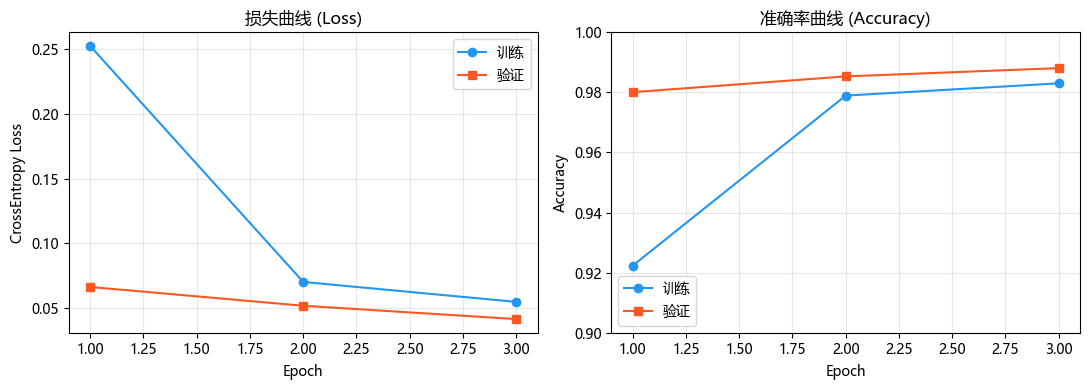

训练最终验证准确率: 0.9880833333333333
如果 Loss 持续下降而 Accuracy 持续上升，说明模型还在学习。
如果两者趋于平稳，可以考虑增加 epoch 或调整学习率。


In [14]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Loss 曲线
axes[0].plot(epochs_range, history["train_loss"], "o-", label="训练", color="#2196F3")
axes[0].plot(epochs_range, history["val_loss"], "s-", label="验证", color="#FF5722")
axes[0].set_title("损失曲线 (Loss)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy 曲线
axes[1].plot(epochs_range, history["train_accuracy"], "o-", label="训练", color="#2196F3")
axes[1].plot(epochs_range, history["val_accuracy"], "s-", label="验证", color="#FF5722")
axes[1].set_title("准确率曲线 (Accuracy)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.9, 1.0)  # 放大看差异

plt.tight_layout()
plt.show()
print("训练最终验证准确率:", history["best_val_accuracy"])
print("如果 Loss 持续下降而 Accuracy 持续上升，说明模型还在学习。")
print("如果两者趋于平稳，可以考虑增加 epoch 或调整学习率。")


## 11) 模型评估：混淆矩阵与分类报告

训练完成后，我们需要在验证集上全面评估模型表现。

**混淆矩阵（Confusion Matrix）**：
- 行 = 真实类别，列 = 预测类别
- 对角线 = 预测正确的样本数
- 非对角线 = 被误分类的样本

**分类报告**：每类的 Precision（精确率）、Recall（召回率）、F1-score

- **Precision** = TP / (TP + FP) — 预测为该类中真正正确的比例
- **Recall** = TP / (TP + FN) — 真实为该类中被正确找出的比例
- **F1** = 2 × P × R / (P + R) — 精确率和召回率的调和平均


验证集准确率: 0.9881 (98.81%)


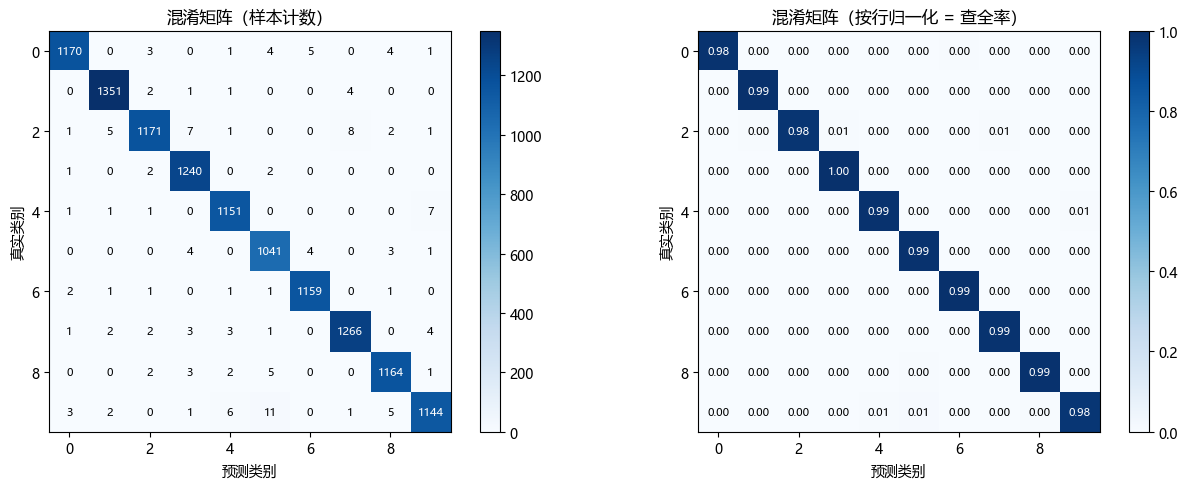

,precision,recall,f1-score,support
类别,,,,
0,0.9924,0.9848,0.9886,1188.0
1,0.9919,0.9941,0.9930,1359.0
2,0.9890,0.9791,0.9840,1196.0
3,0.9849,0.9960,0.9904,1245.0
4,0.9871,0.9914,0.9893,1161.0
5,0.9775,0.9886,0.9830,1053.0
6,0.9923,0.9940,0.9931,1166.0
7,0.9898,0.9875,0.9887,1282.0
8,0.9873,0.9890,0.9881,1177.0



F1 最高: 数字 6 (0.9931)
F1 最低: 数字 9 (0.9811) — 容易和哪些数字混淆？看混淆矩阵！


In [15]:
# 加载最佳 checkpoint
checkpoint = torch.load(
    outputs_dir / "checkpoints" / "best_model.pt", map_location=device
)
eval_model = SmallCNN(num_classes=config.num_classes, in_channels=config.in_channels).to(device)
eval_model.load_state_dict(checkpoint["model_state_dict"])
eval_model.eval()

# 收集验证集全部预测
all_images_list, all_labels_list, all_preds_list = [], [], []

with torch.no_grad():
    for batch_imgs, batch_lbls in val_loader:
        logits = eval_model(batch_imgs.to(device))
        preds = logits.argmax(dim=1).cpu()
        all_images_list.append(batch_imgs.cpu())
        all_labels_list.append(batch_lbls.cpu())
        all_preds_list.append(preds)

images_val = torch.cat(all_images_list, dim=0)
y_true = torch.cat(all_labels_list, dim=0)
y_pred = torch.cat(all_preds_list, dim=0)

acc = float((y_true == y_pred).float().mean().item())
print(f"验证集准确率: {acc:.4f} ({acc*100:.2f}%)")

# ---- 混淆矩阵 ----
cm = confusion_matrix(y_true.numpy(), y_pred.numpy(), labels=list(range(10)))
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)  # 按行归一化

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 计数版
im0 = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("混淆矩阵（样本计数）")
axes[0].set_xlabel("预测类别"); axes[0].set_ylabel("真实类别")
for i in range(10):
    for j in range(10):
        v = int(cm[i, j])
        axes[0].text(j, i, str(v), ha="center", va="center",
                     color="white" if v > cm.max()/2 else "black", fontsize=8)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# 归一化版
im1 = axes[1].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("混淆矩阵（按行归一化 = 查全率）")
axes[1].set_xlabel("预测类别"); axes[1].set_ylabel("真实类别")
for i in range(10):
    for j in range(10):
        axes[1].text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                     color="white" if cm_norm[i,j] > 0.5 else "black", fontsize=8)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

# ---- 分类报告 ----
report = classification_report(y_true.numpy(), y_pred.numpy(), digits=4, output_dict=True)
per_class = {str(i): report[str(i)] for i in range(10)}
df_report = pd.DataFrame(per_class).T[["precision", "recall", "f1-score", "support"]]
df_report.index.name = "类别"
df_report = df_report.round(4)
display(df_report)

best_class = df_report["f1-score"].idxmax()
worst_class = df_report["f1-score"].idxmin()
print(f"\nF1 最高: 数字 {best_class} ({df_report.loc[best_class, 'f1-score']:.4f})")
print(f"F1 最低: 数字 {worst_class} ({df_report.loc[worst_class, 'f1-score']:.4f}) — 容易和哪些数字混淆？看混淆矩阵！")


## 12) 误分类分析：模型在哪些样本上犯错？

理解模型的错误模式是改进模型的关键。我们找出：
1. **错得最自信的样本**：模型给错误预测很高概率 — 说明模型有"盲点"
2. **典型误分类对**：比如真实是 4，预测是 9 — 说明某些类别容易混淆


验证集总样本: 12000
误分类样本: 143 (1.19%)


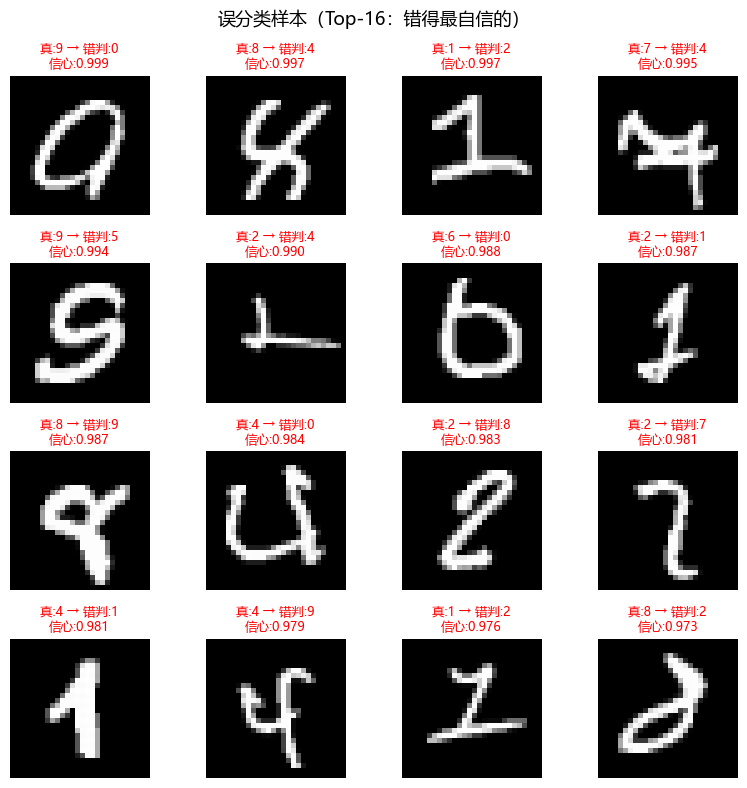


最常见的误分类对（真实 → 预测）:
  9 → 5: 11 次
  2 → 7: 8 次
  4 → 9: 7 次
  2 → 3: 7 次
  9 → 4: 6 次
  0 → 6: 5 次
  9 → 8: 5 次
  2 → 1: 5 次
  8 → 5: 5 次
  1 → 7: 4 次


In [16]:
# 计算每个样本的预测概率
logits_val = []
with torch.no_grad():
    for batch_imgs, _ in val_loader:
        logits_val.append(eval_model(batch_imgs.to(device)).cpu())
logits_val = torch.cat(logits_val, dim=0)
probs_val = F.softmax(logits_val, dim=1)
pred_conf = probs_val[range(len(y_pred)), y_pred]  # 预测类别的置信度

# 找出误分类样本
wrong_mask = (y_pred != y_true)
wrong_indices = torch.where(wrong_mask)[0]
n_wrong = len(wrong_indices)

print(f"验证集总样本: {len(y_true)}")
print(f"误分类样本: {n_wrong} ({n_wrong/len(y_true)*100:.2f}%)")

if n_wrong == 0:
    print("\\n太棒了，没有误分类样本！")
else:
    # 按"错得最自信"排序
    wrong_sorted = wrong_indices[torch.argsort(pred_conf[wrong_indices], descending=True)]
    topk = wrong_sorted[:16]

    # 可视化
    show_imgs = (images_val[topk] * 0.5 + 0.5).clamp(0, 1)
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for ax, img, t, p, conf in zip(
        axes.flatten(), show_imgs, y_true[topk], y_pred[topk], pred_conf[topk]
    ):
        ax.imshow(img.squeeze(0), cmap="gray")
        color = "red" if conf > 0.8 else "black"
        ax.set_title(f"真:{int(t)} → 错判:{int(p)}\n信心:{float(conf):.3f}", fontsize=9, color=color)
        ax.axis("off")
    plt.suptitle("误分类样本（Top-16：错得最自信的）", fontsize=13)
    plt.tight_layout()
    plt.show()

    # 统计最常见的误分类对
    print("\n最常见的误分类对（真实 → 预测）:")
    from collections import Counter
    error_pairs = [(int(y_true[i]), int(y_pred[i])) for i in wrong_indices[:].tolist()]
    for (t, p), count in Counter(error_pairs).most_common(10):
        print(f"  {t} → {p}: {count} 次")


## 13) 对无标签图片预测并导出 CSV

训练好的模型最常见的用途：对新的、没有标签的图片进行批量预测。

我们创建一个简单的预测数据集，从验证集中抽一些图片模拟"新图片"，导出预测结果。

导出格式为 CSV：`filename,prediction`，这是作业提交的常见格式。


已创建 12 张演示图片到 E:\ALL\学习\AI导论作业-识别手写数字\.worktrees\baseline\outputs\predictions\demo_images

预测结果已导出到: E:\ALL\学习\AI导论作业-识别手写数字\.worktrees\baseline\outputs\predictions\predictions_demo.csv
前 10 行预览:
  sample_000.png            → 预测数字: 2
  sample_001.png            → 预测数字: 8
  sample_002.png            → 预测数字: 7
  sample_003.png            → 预测数字: 9
  sample_004.png            → 预测数字: 2
  sample_005.png            → 预测数字: 1
  sample_006.png            → 预测数字: 5
  sample_007.png            → 预测数字: 2
  sample_008.png            → 预测数字: 8
  sample_009.png            → 预测数字: 6


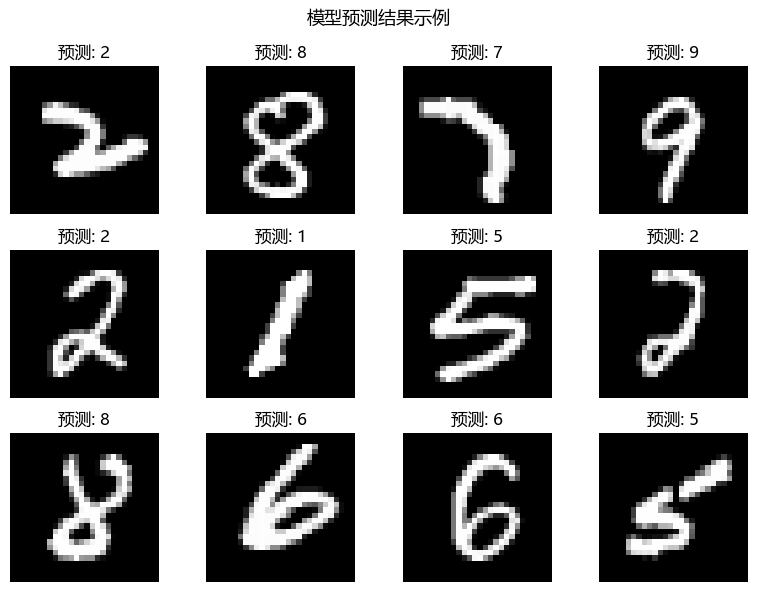

In [17]:
class PredictionDataset(Dataset):
    """从文件夹加载无标签图片用于预测。"""
    def __init__(self, image_dir: Path, image_size: int = 28):
        self.image_dir = Path(image_dir)
        self.image_paths = sorted(
            p for p in self.image_dir.glob("*")
            if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
        )
        if not self.image_paths:
            raise ValueError(f"目录 {image_dir} 中没有图片文件")

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        return self.transform(img), img_path.name


# 演示：用验证集中的图片模拟"新图片"预测
# 实际操作中这里改为你的无标签图片目录
demo_pred_dir = outputs_dir / "predictions" / "demo_images"
demo_pred_dir.mkdir(parents=True, exist_ok=True)

# 从验证集拷贝几张图片做演示
for i in range(12):
    img_tensor = images_val[i]
    img_pil = transforms.ToPILImage()((img_tensor * 0.5 + 0.5).clamp(0, 1))
    img_pil.save(demo_pred_dir / f"sample_{i:03d}.png")

print(f"已创建 {len(list(demo_pred_dir.glob('*.png')))} 张演示图片到 {demo_pred_dir}")

# 预测
pred_dataset = PredictionDataset(demo_pred_dir, image_size=config.image_size)
pred_loader = DataLoader(pred_dataset, batch_size=config.batch_size, shuffle=False)

rows = []
with torch.no_grad():
    for batch_imgs, filenames in pred_loader:
        logits = eval_model(batch_imgs.to(device))
        predictions = logits.argmax(dim=1).cpu().tolist()
        rows.extend(zip(filenames, predictions))

# 导出 CSV
csv_path = outputs_dir / "predictions" / "predictions_demo.csv"
with csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["filename", "prediction"])
    writer.writerows(rows)

print(f"\n预测结果已导出到: {csv_path}")
print("前 10 行预览:")
for row in rows[:10]:
    print(f"  {row[0]:25s} → 预测数字: {row[1]}")

# 展示预测结果
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for ax, (fname, pred), i in zip(axes.flatten(), rows[:12], range(12)):
    img = Image.open(demo_pred_dir / fname)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"预测: {pred}")
    ax.axis("off")
plt.suptitle("模型预测结果示例", fontsize=13)
plt.tight_layout()
plt.show()


## 14) 总结与改进方向

### 你学到了什么

| 知识点 | 对应章节 |
|--------|---------|
| 图像数据 EDA（探索性分析） | §2 数据理解 |
| 预处理流水线（Transform Pipeline） | §3 图像预处理 |
| DataLoader 与 batch 形状 | §4 DataLoader |
| CNN 结构与参数量计算 | §5 CNN 模型 |
| Logits vs 概率（Softmax） | §6 前向传播 |
| 交叉熵损失的含义 | §7 损失函数 |
| 反向传播 + 梯度更新（Adam） | §8 反向传播演示 |
| 完整训练循环（train/eval 模式） | §9 完整训练 |
| 训练曲线解读（过拟合/欠拟合） | §10 训练曲线 |
| 混淆矩阵与分类报告 | §11 模型评估 |
| 误分类分析与模型盲点 | §12 误分类分析 |
| 模型部署与预测导出 | §13 预测导出 |

### 改进方向（提升准确率）

当前模型在 MNIST 上达到 **98%+** 准确率。如果想进一步提升：

1. **更多 epoch**：3→10，但要注意过拟合
2. **数据增强**：训练时启用 `augment=True`（随机旋转+平移）
3. **学习率调度**：使用 `ReduceLROnPlateau` 在验证 loss 横盘时自动降低学习率
4. **更深的网络**：加一层 Conv 或增加通道数（32→64, 64→128）
5. **Batch Normalization**：在 Conv 后加 BN 层，加速收敛
6. **更长的训练 + Early Stopping**：训练更多 epoch，但验证 accuracy 不再提升时自动停止

### 常见陷阱

- ❌ 忘记 `model.eval()` 导致验证时 Dropout 仍生效
- ❌ 验证时用了数据增强
- ❌ 在测试集上调超参数（信息泄露）
- ❌ `torch.no_grad()` 内做 backward（不会报错但梯度为 None）
- ❌ 对归一化后的图像直接可视化（看起来会很奇怪，记得反归一化）

---

> **作业提示**：如果老师提供了隐藏测试集，确保用完全相同的预处理（Resize → ToTensor → Normalize）和相同的 checkpoint 格式。祝你好运！ 🎉
